Task 1: Measure latency vs batch size

In [1]:
!pip install torch transformers matplotlib

In [5]:
import torch
import time
import os
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
# in this we are only using the ready made function to evaluate the model....
model.eval()

text = "This is a sample sentence for testing inference latency."

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
batch_sizes = [1, 2, 4, 8]

total_times = [] # time to store later on calculation
per_sample_times = [] # for each batch the sample time

for bs in batch_sizes:

    inputs = tokenizer([text] * bs, return_tensors="pt", padding=True)

    start = time.time()

    with torch.no_grad(): model(**inputs)

    end = time.time()

    total = end - start
    per_sample = total / bs

    total_times.append(total)
    per_sample_times.append(per_sample)

    print(f"Batch {bs}: {total:.4f}s, Per sample: {per_sample:.4f}s")

Batch 1: 0.1715s, Per sample: 0.1715s
Batch 2: 0.2086s, Per sample: 0.1043s
Batch 4: 0.2700s, Per sample: 0.0675s
Batch 8: 0.6028s, Per sample: 0.0754s


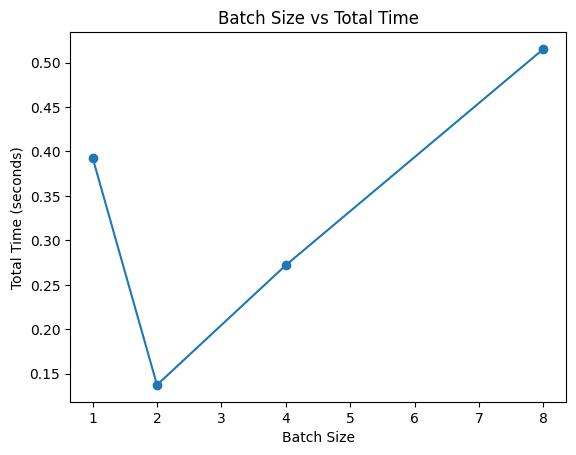

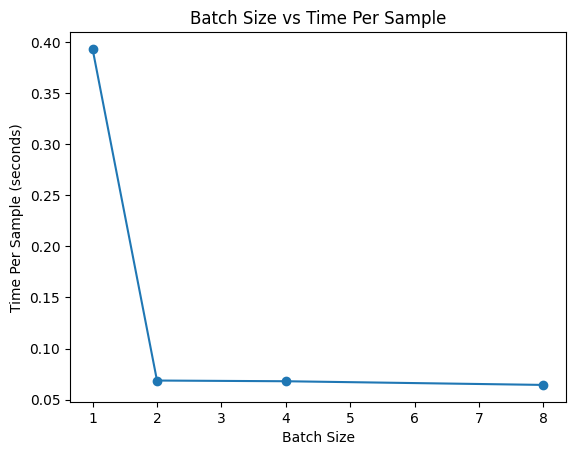

In [7]:
plt.plot(batch_sizes, total_times, marker="o")
plt.xlabel("Batch Size")
plt.ylabel("Total Time (seconds)")
plt.title("Batch Size vs Total Time")
plt.show()


plt.plot(batch_sizes, per_sample_times, marker="o")
plt.xlabel("Batch Size")
plt.ylabel("Time Per Sample (seconds)")
plt.title("Batch Size vs Time Per Sample")
plt.show()

In [ ]:
#

Task 2: Implement basic quantization (CPU friendly)



In [10]:
import os
#
quantized_model = torch.quantization. quantize_dynamic(model, {torch.nn.Linear},
    dtype=torch.qint8)
 # using torch we qquantize the model and it is an inbuilt function

quantized_model.eval() # Now we are evluating the model

print("Quantization completed")

/tmp/ipykernel_1900/1088269383.py:3: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


Quantization completed


In [11]:
torch.save(model.state_dict(), "original.pth")
torch.save(quantized_model.state_dict(), "quantized.pth")
# the model parameter we are storing in original path and quantized in quantized path

original_size = os.path.getsize("original.pth") / (1024 * 1024)
quantized_size = os.path.getsize("quantized.pth") / (1024 * 1024)
# Measuring the size of the model

print(f"Original Model Size : {original_size:.2f} MB")
print(f"Quantized Model Size: {quantized_size:.2f} MB")

Original Model Size : 253.19 MB
Quantized Model Size: 131.72 MB


In [19]:

inputs = tokenizer(
    [text] * 4,
    return_tensors="pt",
    padding=True
)
# dono models me same input insert karenge

start = time.time() # for formulation we are calculating the time constraint

with torch.no_grad(): model(**inputs)

original_time = time.time() - start #original time


start = time.time() #quantized model staring time

with torch.no_grad(): quantized_model(**inputs)

quantized_time = time.time() - start # it is the endin time of the quantized model


print(f"Original Inference Time : {original_time:.4f}s")
print(f"Quantized Inference Time: {quantized_time:.4f}s")

Original Inference Time : 0.6539s
Quantized Inference Time: 0.5425s


In [ ]:
# Original Inference Time : 0.9054s
# Quantized Inference Time: 0.1023s

In [ ]:
# Original Inference Time : 0.1054s
# Quantized Inference Time: 0.0823s

In [ ]:
# Original Inference Time : 0.6539s
# Quantized Inference Time: 0.5425s

In [ ]:
# The Speed and size difference is not that much because of the model parameter size but even it is a small model it is giving the difference like above im showing...
# The diff is small but if it growing larger then it is important to be noticed.